# Shot Distributions

This notebook explores the distributions of key shot-level variables within the NBA shot quality dataset.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Loading in Datasets

seasons = [
    "2013-14","2014-15","2015-16","2016-17",
    "2017-18","2018-19","2019-20","2020-21",
    "2021-22","2022-23","2023-24","2024-25",
    "2025-26"
]

dfs = []

for season in seasons:
    temp = pd.read_parquet(
        f"data/raw/shots/shots_{season}.parquet"
    )
    dfs.append(temp)

shots = pd.concat(dfs, ignore_index=True)

# Shot Distance Distribution

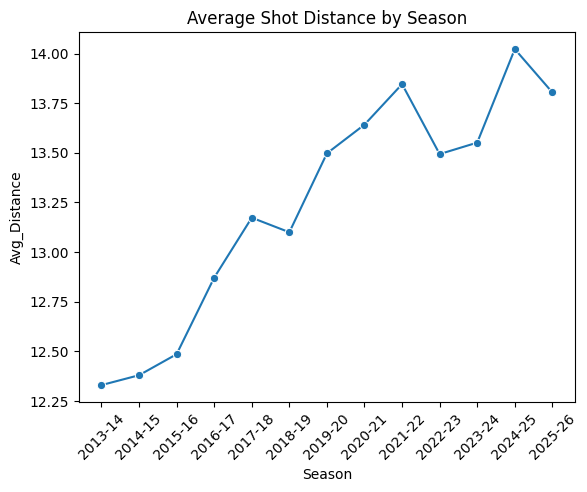

In [9]:
avg_distance = []

for season in seasons:
    temp = pd.read_parquet(f"data/raw/shots/shots_{season}.parquet")

    avg_distance.append({"Season": season, "Avg_Distance": temp["SHOT_DISTANCE"].mean()})

avg_distance = pd.DataFrame(avg_distance)

sns.lineplot(data=avg_distance, x="Season", y="Avg_Distance", marker="o")

plt.title("Average Shot Distance by Season")
plt.xticks(rotation=45)
plt.show()

# Shot Type and Shot Success

In [13]:
shot_trends = []

for season in seasons:
    temp = pd.read_parquet(f"data/raw/shots/shots_{season}.parquet")

    two_pt = temp[temp["SHOT_TYPE"] == "2PT Field Goal"]
    three_pt = temp[temp["SHOT_TYPE"] == "3PT Field Goal"]

    shot_trends.append({
        "Season": season,

        "2PT_Attempt_Pct":
            len(two_pt) / len(temp) * 100,

        "3PT_Attempt_Pct":
            len(three_pt) / len(temp) * 100,

        "2PT_FG_Pct":
            two_pt["SHOT_MADE_FLAG"].mean() * 100,

        "3PT_FG_Pct":
            three_pt["SHOT_MADE_FLAG"].mean() * 100
    })

shot_trends = pd.DataFrame(shot_trends)

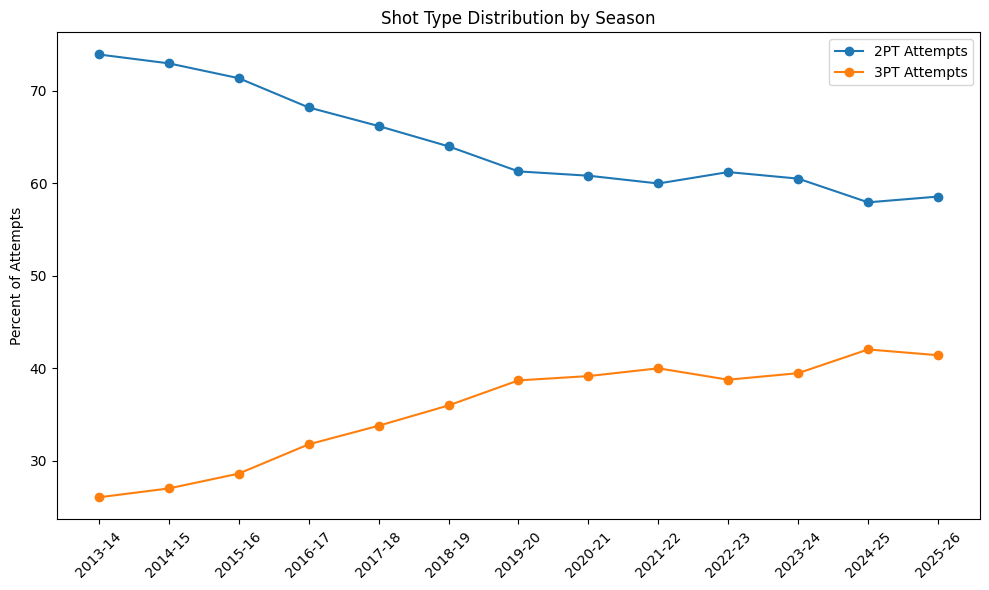

In [14]:
plt.figure(figsize=(10,6))

plt.plot(shot_trends["Season"], shot_trends["2PT_Attempt_Pct"], marker="o",label="2PT Attempts")

plt.plot(shot_trends["Season"], shot_trends["3PT_Attempt_Pct"], marker="o", label="3PT Attempts")

plt.title("Shot Type Distribution by Season")
plt.ylabel("Percent of Attempts")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

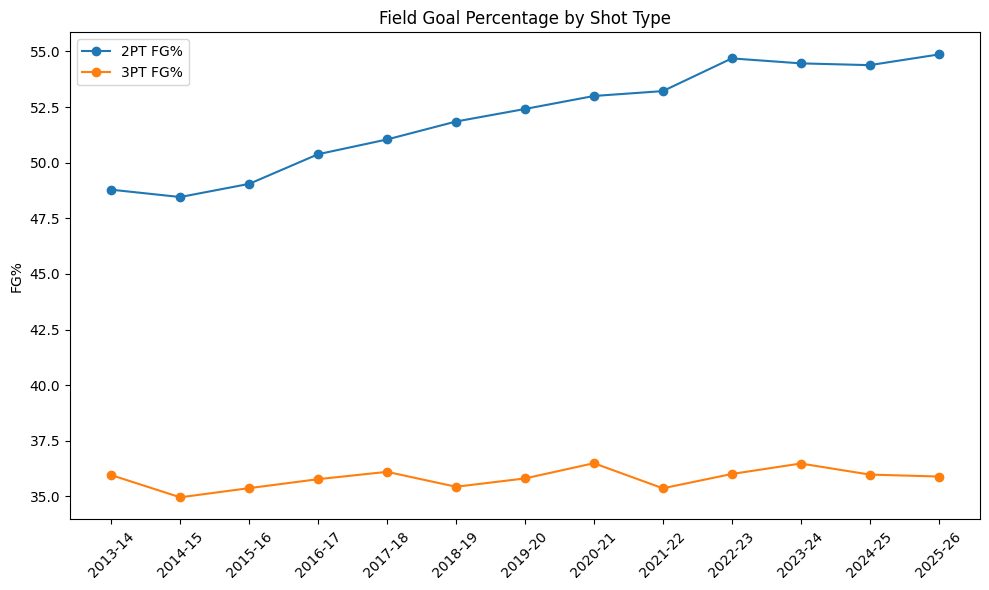

In [16]:
plt.figure(figsize=(10,6))

plt.plot(shot_trends["Season"], shot_trends["2PT_FG_Pct"], marker="o", label="2PT FG%")

plt.plot(shot_trends["Season"], shot_trends["3PT_FG_Pct"], marker="o", label="3PT FG%")

plt.title("Field Goal Percentage by Shot Type")
plt.ylabel("FG%")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [17]:
zone_data = []

for season in seasons:
    temp = pd.read_parquet(f"data/raw/shots/shots_{season}.parquet")

    zone_pct = (temp["SHOT_ZONE_BASIC"].value_counts(normalize=True).mul(100))

    for zone, pct in zone_pct.items():
        zone_data.append({"Season": season, "Zone": zone, "Percentage": pct})

zone_df = pd.DataFrame(zone_data)

zone_df.head()

,Season,Zone,Percentage
0,2013-14,Restricted Area,32.241874
1,2013-14,Mid-Range,26.792665
2,2013-14,Above the Break 3,19.181451
3,2013-14,In The Paint (Non-RA),14.901402
4,2013-14,Left Corner 3,3.519843


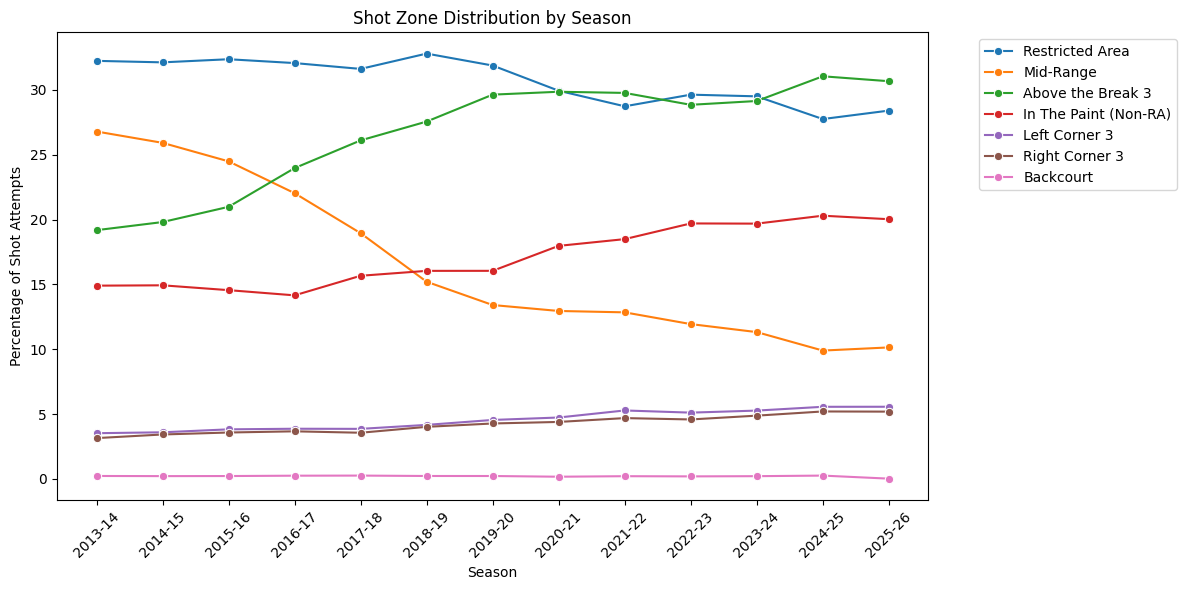

In [18]:
plt.figure(figsize=(12,6))

sns.lineplot(data=zone_df, x="Season", y="Percentage", hue="Zone", marker="o")

plt.title("Shot Zone Distribution by Season")
plt.ylabel("Percentage of Shot Attempts")
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()